In [16]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from PIL import Image
from sklearn import preprocessing
from IPython.display import display
import os

In [17]:
DATA_PATH = 'data/data_stream-oper.nc'

In [18]:
dataset = xr.open_dataset(DATA_PATH).sel(valid_time=slice('2020-01-01', '2020-01-02'))
print(dataset.variables)

Frozen({'number': <xarray.Variable ()> Size: 8B
[1 values with dtype=int64]
Attributes:
    long_name:      ensemble member numerical id
    units:          1
    standard_name:  realization, 'valid_time': <xarray.IndexVariable 'valid_time' (valid_time: 8)> Size: 64B
array(['2020-01-01T00:00:00.000000000', '2020-01-01T06:00:00.000000000',
       '2020-01-01T12:00:00.000000000', '2020-01-01T18:00:00.000000000',
       '2020-01-02T00:00:00.000000000', '2020-01-02T06:00:00.000000000',
       '2020-01-02T12:00:00.000000000', '2020-01-02T18:00:00.000000000'],
      dtype='datetime64[ns]')
Attributes:
    long_name:      time
    standard_name:  time, 'latitude': <xarray.IndexVariable 'latitude' (latitude: 33)> Size: 264B
array([55.16, 54.91, 54.66, 54.41, 54.16, 53.91, 53.66, 53.41, 53.16, 52.91,
       52.66, 52.41, 52.16, 51.91, 51.66, 51.41, 51.16, 50.91, 50.66, 50.41,
       50.16, 49.91, 49.66, 49.41, 49.16, 48.91, 48.66, 48.41, 48.16, 47.91,
       47.66, 47.41, 47.16])
Attributes:
  

In [64]:

dataset.data_vars


Data variables:
    u10      (valid_time, latitude, longitude) float32 35kB 4.362 ... 1.336
    v10      (valid_time, latitude, longitude) float32 35kB 2.882 ... 0.6417
    d2m      (valid_time, latitude, longitude) float32 35kB 276.0 ... 265.7
    t2m      (valid_time, latitude, longitude) float32 35kB 280.9 ... 270.6
    msl      (valid_time, latitude, longitude) float32 35kB 1.033e+05 ... 1.0...
    tp       (valid_time, latitude, longitude) float32 35kB 0.0 0.0 ... 0.0 0.0

In [19]:
def get_wind_speed(u, v):
    func = lambda x, y: np.sqrt(x**2 + y**2)
    return xr.apply_ufunc(func, u, v)

In [56]:
print(list(dataset.variables)[5:])

['u10', 'v10', 'd2m', 't2m', 'msl', 'tp']


In [42]:
dataset['u10'][0, :32, :32].values.shape

(32, 32)

In [55]:
test = np.array([dataset[var][0, :32, :32].values for var in list(dataset.variables)[5:]])
print(test.shape)

(6, 32, 32)


In [20]:
u10 = dataset['u10'][:, :32, :32]
v10 = dataset['v10'][:, :32, :32]
# add wind speed
wind_speed = get_wind_speed(u10, v10)
print(wind_speed)

<xarray.DataArray (valid_time: 8, latitude: 32, longitude: 32)> Size: 33kB
array([[[ 5.228447  ,  5.138687  ,  5.1074195 , ...,  8.031779  ,
          7.867828  ,  7.7976556 ],
        [ 4.868079  ,  4.762705  ,  4.6951246 , ...,  8.6730175 ,
          8.533914  ,  8.312901  ],
        [ 4.4959393 ,  4.4065704 ,  4.322227  , ...,  8.293587  ,
          8.313567  ,  8.427291  ],
        ...,
        [ 3.0372186 ,  2.7386472 ,  1.2823232 , ...,  0.94917655,
          1.1161265 ,  1.239449  ],
        [ 3.1976278 ,  2.904613  ,  1.5843053 , ...,  1.3322664 ,
          1.4205359 ,  1.5028625 ],
        [ 3.0062776 ,  2.711911  ,  1.8802997 , ...,  1.079965  ,
          1.5873934 ,  1.9574336 ]],

       [[ 8.023698  ,  7.975404  ,  8.000065  , ...,  9.2618685 ,
          9.298133  ,  9.456752  ],
        [ 7.602591  ,  7.536484  ,  7.540251  , ...,  9.5950165 ,
          9.694255  ,  9.7182    ],
        [ 7.168791  ,  7.0982146 ,  7.07836   , ...,  8.899332  ,
          9.120132  ,  9.384

In [21]:
if not os.path.exists('data/images'):
    os.makedirs('data/images')

In [22]:
#rescale to 0-1
#change to -1 to 1

min_max_scaler = preprocessing.MinMaxScaler(feature_range=(-1, 1))
data_arr = []
#create 32x32 images of windspeed
for i, data  in enumerate(wind_speed):
    data = data.values
    data = min_max_scaler.fit_transform(data)
    data = np.uint8(data * 255)
    data_arr.append(data)
    img = Image.fromarray(data)
    
    img.save(f'data/images/hr_{i}.png')

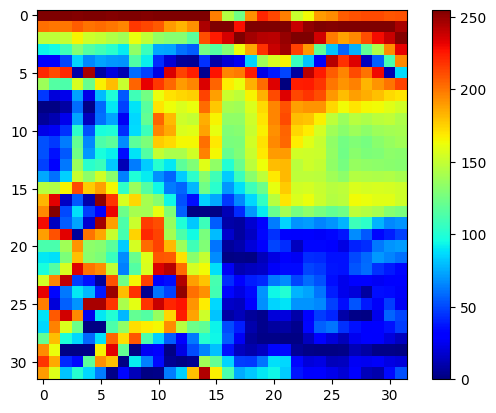

In [23]:
#make colormap of wind speed
plt.imshow(data_arr[0], cmap='jet', interpolation='nearest')
plt.colorbar()

In [24]:
# Low resolution images, apply average pooling of 2x2
def average_pooling(data, scale):
    new_h, new_w = data.shape[0]//scale, data.shape[1]//scale
    
    data = data.reshape(new_h,scale ,new_w,scale).mean(axis=(1, 3))
    # to uint8
    data = np.uint8(data)
    return data

data_arr_lr_2 = []

for i,data in enumerate(data_arr):

    data = average_pooling(data, 2)
    data_arr_lr_2.append(data)
    img = Image.fromarray(data)
    img.save(f'data/images/lr_2x2_{i}.png')
data_arr_lr_8 = []  
for i, data in enumerate(data_arr):
    data = average_pooling(data, 8)
    img = Image.fromarray(data)
    data_arr_lr_8.append(data)
    img.save(f'data/images/lr_8x8_{i}.png')
    


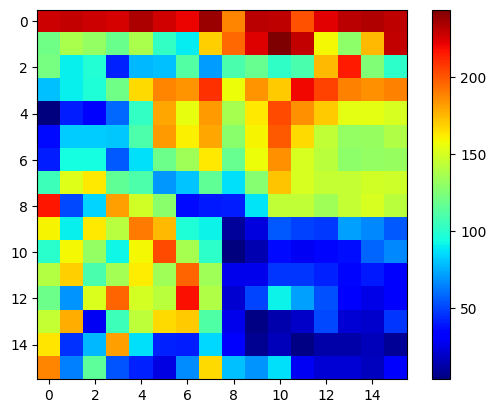

In [25]:
plt.imshow(data_arr_lr_2[0], cmap='jet', interpolation='nearest')
plt.colorbar()


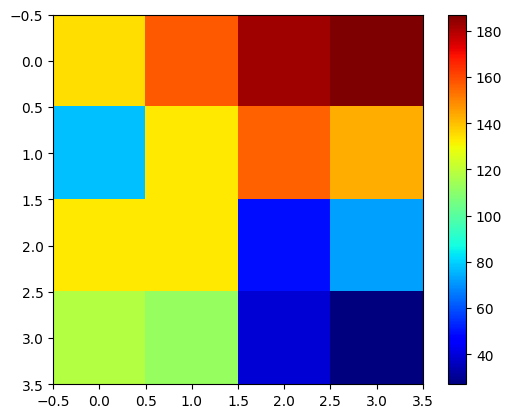

In [26]:
plt.imshow(data_arr_lr_8[0], cmap='jet', interpolation='nearest')
plt.colorbar()

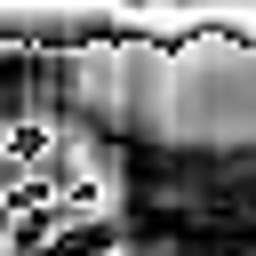

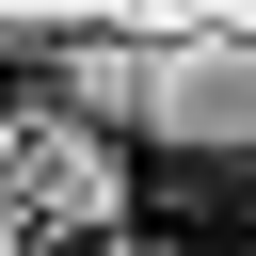

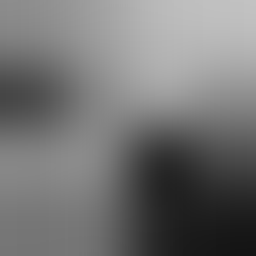

In [27]:
display(Image.open('data/images/hr_0.png').resize((256, 256)))
display(Image.open('data/images/lr_2x2_0.png').resize((256, 256)))
display(Image.open('data/images/lr_8x8_0.png').resize((256, 256)))

huggingface_hub version >0.24 does not work with super_image

In [28]:
import huggingface_hub
assert(huggingface_hub.__version__ == "0.24.0")

In [29]:
from datasets import load_dataset
from super_image import Trainer, TrainingArguments, EdsrModel, EdsrConfig
import torch
from torch.utils.data import Dataset
import torch.nn as nn

In [30]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
scale = 2
config = EdsrConfig(scale=2)
model = EdsrModel(config).to(device)

In [31]:
#from Lucas' code, modify model to fit grayscale data

class MeanShift(nn.Conv2d):
    def __init__(self, rgb_range, rgb_mean=0.5, rgb_std=1.0, sign=-1):
        # modify kernel to size 1 for single input channel
        super(MeanShift, self).__init__(1, 1, kernel_size=1)

        # adjust weight and bias for a single input channel
        std = torch.Tensor([rgb_std])
        self.weight.data = torch.eye(1).view(1, 1, 1, 1)
        self.weight.data.div_(std.view(1, 1, 1, 1))
        self.bias.data = sign * rgb_range * torch.Tensor([rgb_mean])
        self.bias.data.div_(std)
        self.requires_grad = False


# values
rgb_range = 255.0
rgb_mean_value = 0.5
rgb_stdev = 1.0

# create instance of Meanshift
mean_shift_module = MeanShift(rgb_range, rgb_mean_value, rgb_stdev)


# modify
model.sub_mean = MeanShift(rgb_range, rgb_mean=rgb_mean_value, rgb_std=rgb_stdev)
model.add_mean = MeanShift(rgb_range, sign=1, rgb_mean= rgb_mean_value, rgb_std=rgb_stdev)
model.head = torch.nn.Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

model.tail = torch.nn.Sequential(
            torch.nn.Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            torch.nn.PixelShuffle(upscale_factor=2),
            torch.nn.Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)


In [32]:
model

EdsrModel(
  (sub_mean): MeanShift(1, 1, kernel_size=(1, 1), stride=(1, 1))
  (add_mean): MeanShift(1, 1, kernel_size=(1, 1), stride=(1, 1))
  (head): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (body): Sequential(
    (0): ResBlock(
      (body): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (1): ResBlock(
      (body): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (2): ResBlock(
      (body): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (3): ResBlo